In [46]:
import pandas as pd

dff = pd.read_csv("../data/DFF.csv")
fomc = pd.read_csv("../data/fomc_dates.csv")

dff["observation_date"] = pd.to_datetime(dff["observation_date"])
fomc["decision_date"] = pd.to_datetime(fomc["decision_date"])

print("DFF:")
print(dff.head())

print("\nFOMC:")
print(fomc.head())

print("\nDFF period:")
print(dff["observation_date"].min(), "to", dff["observation_date"].max())

print("\nNumber of FOMC meetings:")
print(len(fomc))

DFF:
  observation_date  DFF
0       2021-08-06  0.1
1       2021-08-07  0.1
2       2021-08-08  0.1
3       2021-08-09  0.1
4       2021-08-10  0.1

FOMC:
   year meeting_start decision_date
0  2021    2021-01-26    2021-01-27
1  2021    2021-03-16    2021-03-17
2  2021    2021-04-27    2021-04-28
3  2021    2021-06-15    2021-06-16
4  2021    2021-07-27    2021-07-28

DFF period:
2021-08-06 00:00:00 to 2026-08-06 00:00:00

Number of FOMC meetings:
40


In [47]:
dff = dff.sort_values("observation_date")

fomc["decision_date"] = pd.to_datetime(fomc["decision_date"])

merged = fomc.merge(
    dff,
    left_on="decision_date",
    right_on="observation_date",
    how="left"
)

merged["DFF_change"] = merged["DFF"].diff()


In [48]:
valid = merged.dropna(subset=["DFF"]).copy()

valid["DFF_change"] = valid["DFF"].diff()

valid = valid.dropna(subset=["DFF_change"])

valid[["decision_date", "DFF", "DFF_change"]].to_csv(
    "../data/fomc_dff_decisions.csv",
    index=False
)

valid[["decision_date", "DFF", "DFF_change"]].head(15)

,decision_date,DFF,DFF_change
6,2021-11-03,0.08,0.00
7,2021-12-15,0.08,0.00
8,2022-01-26,0.08,0.00
9,2022-03-16,0.08,0.00
10,2022-05-04,0.33,0.25
11,2022-06-15,0.83,0.50
12,2022-07-27,1.58,0.75
13,2022-09-21,2.33,0.75
14,2022-11-02,3.08,0.75
15,2022-12-14,3.83,0.75


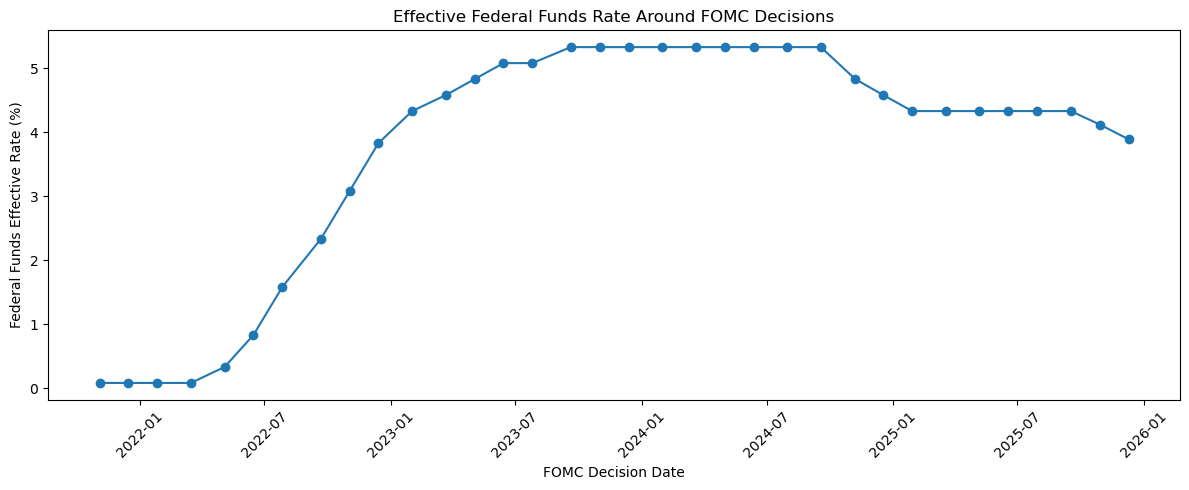

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    valid["decision_date"],
    valid["DFF"],
    marker="o"
)

plt.xlabel("FOMC Decision Date")
plt.ylabel("Federal Funds Effective Rate (%)")
plt.title("Effective Federal Funds Rate Around FOMC Decisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
import pandas as pd

dgs2 = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS2"
)

dgs2["observation_date"] = pd.to_datetime(dgs2["observation_date"])
dgs2["DGS2"] = pd.to_numeric(dgs2["DGS2"], errors="coerce")

dgs2.head()

,observation_date,DGS2
0,1976-06-01,7.26
1,1976-06-02,7.23
2,1976-06-03,7.22
3,1976-06-04,7.12
4,1976-06-07,7.09


In [51]:
dgs2 = dgs2.sort_values("observation_date")

dgs2["DGS2_change"] = dgs2["DGS2"].diff()

dgs2.head(10)

,observation_date,DGS2,DGS2_change
0,1976-06-01,7.26,NaN
1,1976-06-02,7.23,-0.03
2,1976-06-03,7.22,-0.01
3,1976-06-04,7.12,-0.10
4,1976-06-07,7.09,-0.03
5,1976-06-08,7.11,0.02
6,1976-06-09,7.08,-0.03
7,1976-06-10,7.00,-0.08
8,1976-06-11,7.03,0.03
9,1976-06-14,7.01,-0.02


In [52]:
merged_market = valid.merge(
    dgs2,
    left_on="decision_date",
    right_on="observation_date",
    how="left"
)

merged_market[
    ["decision_date", "DFF", "DFF_change", "DGS2", "DGS2_change"]
].head(20)

,decision_date,DFF,DFF_change,DGS2,DGS2_change
0,2021-11-03,0.08,0.00,0.47,0.01
1,2021-12-15,0.08,0.00,0.69,0.02
2,2022-01-26,0.08,0.00,1.13,0.11
3,2022-03-16,0.08,0.00,1.95,0.10
4,2022-05-04,0.33,0.25,2.66,-0.12
5,2022-06-15,0.83,0.50,3.20,-0.25
6,2022-07-27,1.58,0.75,2.96,-0.06
7,2022-09-21,2.33,0.75,4.02,0.06
8,2022-11-02,3.08,0.75,4.61,0.07
9,2022-12-14,3.83,0.75,4.23,0.01


In [53]:
merged_market[
    ["decision_date", "DFF_change", "DGS2_change"]
].describe()

,decision_date,DFF_change,DGS2_change
count,34,34.000000,34.000000
mean,2023-11-23 16:14:07.058823424,0.112059,-0.028824
min,2021-11-03 00:00:00,-0.500000,-0.270000
25%,2022-11-12 12:00:00,0.000000,-0.080000
50%,2023-11-22 00:00:00,0.000000,-0.015000
75%,2024-12-07 18:00:00,0.250000,0.035000
max,2025-12-10 00:00:00,0.750000,0.120000
std,NaN,0.306869,0.097787


In [54]:
merged_market["abs_DFF_change"] = merged_market["DFF_change"].abs()

merged_market[
    ["decision_date", "DFF_change", "DGS2_change", "abs_DFF_change"]
].sort_values(
    "abs_DFF_change",
    ascending=False
).head(15)

,decision_date,DFF_change,DGS2_change,abs_DFF_change
6,2022-07-27,0.75,-0.06,0.75
7,2022-09-21,0.75,0.06,0.75
8,2022-11-02,0.75,0.07,0.75
9,2022-12-14,0.75,0.01,0.75
24,2024-11-07,-0.50,-0.06,0.50
10,2023-02-01,0.50,-0.12,0.50
5,2022-06-15,0.50,-0.25,0.50
12,2023-05-03,0.25,-0.08,0.25
25,2024-12-18,-0.25,0.10,0.25
26,2025-01-29,-0.25,0.02,0.25


In [55]:
dgs10 = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"
)

dgs10["observation_date"] = pd.to_datetime(dgs10["observation_date"])
dgs10["DGS10"] = pd.to_numeric(dgs10["DGS10"], errors="coerce")

dgs10 = dgs10.sort_values("observation_date")

dgs10["DGS10_change"] = dgs10["DGS10"].diff()

dgs10.head(10)

,observation_date,DGS10,DGS10_change
0,1962-01-02,4.06,NaN
1,1962-01-03,4.03,-0.03
2,1962-01-04,3.99,-0.04
3,1962-01-05,4.02,0.03
4,1962-01-08,4.03,0.01
5,1962-01-09,4.05,0.02
6,1962-01-10,4.07,0.02
7,1962-01-11,4.08,0.01
8,1962-01-12,4.08,0.00
9,1962-01-15,4.10,0.02


In [56]:
merged_market = merged_market.merge(
    dgs10,
    left_on="decision_date",
    right_on="observation_date",
    how="left"
)

merged_market[
    [
        "decision_date",
        "DFF_change",
        "DGS2_change",
        "DGS10_change"
    ]
].head(20)

,decision_date,DFF_change,DGS2_change,DGS10_change
0,2021-11-03,0.00,0.01,0.04
1,2021-12-15,0.00,0.02,0.03
2,2022-01-26,0.00,0.11,0.07
3,2022-03-16,0.00,0.10,0.04
4,2022-05-04,0.25,-0.12,-0.04
5,2022-06-15,0.50,-0.25,-0.16
6,2022-07-27,0.75,-0.06,-0.03
7,2022-09-21,0.75,0.06,-0.06
8,2022-11-02,0.75,0.07,0.03
9,2022-12-14,0.75,0.01,-0.02


In [57]:
statements["url"].head(10)

0    https://www.federalreserve.gov/newsevents/pres...
1    https://www.federalreserve.gov/newsevents/pres...
2    https://www.federalreserve.gov/newsevents/pres...
3    https://www.federalreserve.gov/newsevents/pres...
4    https://www.federalreserve.gov/newsevents/pres...
5    https://www.federalreserve.gov/newsevents/pres...
6    https://www.federalreserve.gov/newsevents/pres...
7    https://www.federalreserve.gov/newsevents/pres...
8    https://www.federalreserve.gov/newsevents/pres...
9    https://www.federalreserve.gov/newsevents/pres...
Name: url, dtype: object

In [58]:
import re

statements["statement_date"] = statements["url"].str.extract(
    r"monetary(\d{8})"
)[0]

statements["statement_date"] = pd.to_datetime(
    statements["statement_date"],
    format="%Y%m%d",
    errors="coerce"
)

statements[["statement_date", "url"]].head(15)

,statement_date,url
0,2026-01-28,https://www.federalreserve.gov/newsevents/pres...
1,2026-03-18,https://www.federalreserve.gov/newsevents/pres...
2,2026-04-29,https://www.federalreserve.gov/newsevents/pres...
3,2026-06-17,https://www.federalreserve.gov/newsevents/pres...
4,2026-07-29,https://www.federalreserve.gov/newsevents/pres...
5,2025-01-29,https://www.federalreserve.gov/newsevents/pres...
6,2025-03-19,https://www.federalreserve.gov/newsevents/pres...
7,2025-05-07,https://www.federalreserve.gov/newsevents/pres...
8,2025-06-18,https://www.federalreserve.gov/newsevents/pres...
9,2025-07-30,https://www.federalreserve.gov/newsevents/pres...


In [59]:
statements = statements.sort_values("statement_date")

merged_statements = fomc.merge(
    statements,
    left_on="decision_date",
    right_on="statement_date",
    how="left"
)

print("FOMC meetings:", len(fomc))
print("Matched statements:", merged_statements["url"].notna().sum())
print("Missing statements:", merged_statements["url"].isna().sum())

merged_statements[
    ["decision_date", "statement_date", "url"]
].head(15)

FOMC meetings: 40
Matched statements: 40
Missing statements: 0


,decision_date,statement_date,url
0,2021-01-27,2021-01-27,https://www.federalreserve.gov/newsevents/pres...
1,2021-03-17,2021-03-17,https://www.federalreserve.gov/newsevents/pres...
2,2021-04-28,2021-04-28,https://www.federalreserve.gov/newsevents/pres...
3,2021-06-16,2021-06-16,https://www.federalreserve.gov/newsevents/pres...
4,2021-07-28,2021-07-28,https://www.federalreserve.gov/newsevents/pres...
5,2021-09-22,2021-09-22,https://www.federalreserve.gov/newsevents/pres...
6,2021-11-03,2021-11-03,https://www.federalreserve.gov/newsevents/pres...
7,2021-12-15,2021-12-15,https://www.federalreserve.gov/newsevents/pres...
8,2022-01-26,2022-01-26,https://www.federalreserve.gov/newsevents/pres...
9,2022-03-16,2022-03-16,https://www.federalreserve.gov/newsevents/pres...


In [60]:
import requests
from bs4 import BeautifulSoup
import time

def get_statement_text(url):
    response = requests.get(url, timeout=20)
    soup = BeautifulSoup(response.text, "html.parser")

    text = soup.get_text(" ", strip=True)

    return text

merged_statements["statement_text"] = merged_statements["url"].apply(
    get_statement_text
)

merged_statements[
    ["decision_date", "statement_text"]
].head(3)

,decision_date,statement_text
0,2021-01-27,ï»¿ Federal Reserve Board - Federal Reserve is...
1,2021-03-17,ï»¿ Federal Reserve Board - Federal Reserve is...
2,2021-04-28,ï»¿ Federal Reserve Board - Federal Reserve is...


In [96]:
merged_statements["statement_text"] = (
    merged_statements["statement_text"]
    .str.replace("\ufeff", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Number of statements:", len(merged_statements))
print("Missing text:", merged_statements["statement_text"].isna().sum())
print("Average text length:", merged_statements["statement_text"].str.len().mean())

Number of statements: 40
Missing text: 0
Average text length: 11233.25


In [97]:
import re

start_phrase = "The Federal Reserve is committed"

merged_statements["clean_text"] = merged_statements["statement_text"].apply(
    lambda x: x[x.find(start_phrase):] if start_phrase in x else None
)

print("Total statements:", len(merged_statements))
print("Missing clean text:", merged_statements["clean_text"].isna().sum())

Total statements: 40
Missing clean text: 32


In [98]:
merged_statements[["decision_date", "clean_text"]].head(3)

,decision_date,clean_text
0,2021-01-27,The Federal Reserve is committed to using its ...
1,2021-03-17,The Federal Reserve is committed to using its ...
2,2021-04-28,The Federal Reserve is committed to using its ...


In [99]:
missing = merged_statements[
    merged_statements["clean_text"].isna()
][["decision_date", "statement_text"]].copy()

for i, row in missing.head(10).iterrows():
    print("\nDATE:", row["decision_date"])
    print(row["statement_text"][:1500])
    print("=" * 80)


DATE: 2022-01-26 00:00:00
ï»¿ Federal Reserve Board - Federal Reserve issues FOMC statement Skip to main content An official website of the United States Government Here's how you know Official websites use .gov A .gov website belongs to an official government organization in the United States. Secure .gov websites use HTTPS A lock ( Lock Locked padlock icon ) or https:// means you've safely connected to the .gov website. Share sensitive information only on official, secure websites. Back to Home Board of Governors of the Federal Reserve System Stay Connected Federal Reserve Facebook Page Federal Reserve Instagram Page Federal Reserve YouTube Page Federal Reserve Flickr Page Federal Reserve LinkedIn Page Federal Reserve Threads Page Federal Reserve X Page Federal Reserve Bluesky Page Subscribe to RSS Subscribe to Email Recent Postings Calendar Publications Site Map A-Z index Careers FAQs Videos Contact Search Submit Search Button Advanced Toggle Dropdown Menu Board of Governors of the

In [100]:
for i, row in missing.head(10).iterrows():
    text = row["statement_text"]
    
    print("\nDATE:", row["decision_date"])
    print("Length:", len(text))
    
    for phrase in [
        "For release at",
        "For immediate release",
        "The Federal Reserve",
        "Recent indicators",
        "The Committee"
    ]:
        print(phrase, "=>", text.find(phrase))


DATE: 2022-01-26 00:00:00
Length: 11471
For release at => 7765
For immediate release => -1
The Federal Reserve => 997
Recent indicators => -1
The Committee => 8766

DATE: 2022-03-16 00:00:00
Length: 10964
For release at => 7763
For immediate release => -1
The Federal Reserve => 997
Recent indicators => -1
The Committee => 8409

DATE: 2022-05-04 00:00:00
Length: 11206
For release at => 7761
For immediate release => -1
The Federal Reserve => 997
Recent indicators => -1
The Committee => 8546

DATE: 2022-06-15 00:00:00
Length: 11104
For release at => 7762
For immediate release => -1
The Federal Reserve => 997
Recent indicators => -1
The Committee => 8435

DATE: 2022-07-27 00:00:00
Length: 10770
For release at => 7762
For immediate release => -1
The Federal Reserve => 997
Recent indicators => 7797
The Committee => 8318

DATE: 2022-09-21 00:00:00
Length: 10777
For release at => 7767
For immediate release => -1
The Federal Reserve => 997
Recent indicators => 7802
The Committee => 8319

DATE:

In [101]:
for i, row in missing.head(5).iterrows():
    text = row["statement_text"]
    pos = text.find("For release at")
    
    print("\nDATE:", row["decision_date"])
    print(text[pos:pos + 2500])
    print("=" * 100)


DATE: 2022-01-26 00:00:00
For release at 2:00 p.m. EST Share Indicators of economic activity and employment have continued to strengthen. The sectors most adversely affected by the pandemic have improved in recent months but are being affected by the recent sharp rise in COVID-19 cases. Job gains have been solid in recent months, and the unemployment rate has declined substantially. Supply and demand imbalances related to the pandemic and the reopening of the economy have continued to contribute to elevated levels of inflation. Overall financial conditions remain accommodative, in part reflecting policy measures to support the economy and the flow of credit to U.S. households and businesses. The path of the economy continues to depend on the course of the virus. Progress on vaccinations and an easing of supply constraints are expected to support continued gains in economic activity and employment as well as a reduction in inflation. Risks to the economic outlook remain, including from

In [102]:
import re

def extract_fomc_text(text):
    pos = text.find("For release at")
    
    if pos == -1:
        return None
    
    text = text[pos:]
    
    share_pos = text.find("Share")
    
    if share_pos == -1:
        return None
    
    return text[share_pos + len("Share"):].strip()


merged_statements["clean_text"] = merged_statements["statement_text"].apply(
    extract_fomc_text
)

print("Total statements:", len(merged_statements))
print("Missing clean text:", merged_statements["clean_text"].isna().sum())
print("Average text length:", merged_statements["clean_text"].str.len().mean())

Total statements: 40
Missing clean text: 0
Average text length: 3434.2


In [107]:
merged_statements[["decision_date", "clean_text"]].head(3)

,decision_date,clean_text
0,2021-01-27,The Federal Reserve is committed to using its ...
1,2021-03-17,The Federal Reserve is committed to using its ...
2,2021-04-28,The Federal Reserve is committed to using its ...


In [108]:
merged_statements[["decision_date", "clean_text"]].tail(5)

,decision_date,clean_text
35,2025-06-18,Although swings in net exports have affected t...
36,2025-07-30,Although swings in net exports continue to aff...
37,2025-09-17,Recent indicators suggest that growth of econo...
38,2025-10-29,Available indicators suggest that economic act...
39,2025-12-10,Available indicators suggest that economic act...


In [109]:
merged_statements["clean_text"].str.len().describe()

count      40.000000
mean     3434.200000
std       446.462805
min      2921.000000
25%      3161.250000
50%      3279.000000
75%      3484.500000
max      4899.000000
Name: clean_text, dtype: float64